In [ ]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import matplotlib
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_validate, KFold, train_test_split
from sklearn.metrics import mean_squared_error
import zipfile, sys
from tqdm import tqdm

random.seed(2718281)
np.random.seed(2718281)

## In this module you will learn how to:

1. Build a nonparametric model of house prices using regression trees
2. Examine random forests and what the hyperparameters correspond to

### The Data

In this module we will re-examine the Housing data. However, instead of assuming the model is linear ($Y = X\beta + \varepsilon$) we will be agnostic about functional form, i.e. $Y=g(X)+\varepsilon$. To estimate the unknown function $g(X)$ we will use Regression Trees and Forests.

In [ ]:
import os
import urllib.request
if not os.path.exists('ahs_clean.zip'):
    urllib.request.urlretrieve("https://github.com/bquistorff/NABE_workbooks/raw/colab/ahs_clean.zip", 'ahs_clean.zip')

In [2]:
# Equivalent to: Housing = read.csv(unzip('ahs_clean.zip'))
with zipfile.ZipFile('ahs_clean.zip') as z:
    csv_name = z.namelist()[0]
    with z.open(csv_name) as f:
        Housing = pd.read_csv(f)

print(f'Dataset dimensions: {Housing.shape}')

# Feature engineering (equivalent to: Housing$LOGSQFT = log(Housing$UNITSF))
Housing['LOGSQFT'] = np.log(Housing['UNITSF'])
Housing['LOGLOT']  = np.log(Housing['LOT'])

Housing.iloc[:10, :10]

Dataset dimensions: (51759, 212)


,LOGVALUE,LOT,UNITSF,CLIMB,DIRAC,NUMAIR,BUSPER,EXCLUS,HOWH,NUMCOLD
0,0.693147,900.0,2314.179989,2.011952,1.51928,1.730885,0.0,0.0,6.0,1.828194
1,0.693147,14520.0,2500.000000,2.011952,1.51928,1.730885,0.0,0.0,10.0,1.828194
2,0.693147,11000.0,7507.000000,2.011952,1.51928,1.000000,0.0,0.0,9.0,1.828194
3,1.609438,23760.0,830.000000,2.011952,1.51928,1.000000,0.0,0.0,10.0,1.828194
4,1.609438,3000.0,1100.000000,2.011952,1.51928,4.000000,0.0,0.0,7.0,1.828194
5,1.609438,44000.0,1000.000000,2.011952,1.51928,1.730885,0.0,0.0,6.0,1.828194
6,1.609438,220000.0,2000.000000,2.011952,1.51928,1.000000,1.0,0.0,8.0,1.828194
7,1.609438,220000.0,1800.000000,2.011952,1.51928,1.730885,0.0,0.0,10.0,1.828194
8,1.609438,33000.0,1200.000000,2.011952,1.51928,1.730885,1.0,0.0,10.0,1.828194
9,1.945910,44000.0,1957.000000,2.011952,1.51928,1.730885,0.0,0.0,8.0,1.828194


Since we already examined this data, let's go ahead and use the larger model with 60 covariates.

In [3]:
train_test, validation = train_test_split(Housing, test_size=0.1, random_state=2718281)

In [4]:
# Equivalent to: train1 = train_test[c(...)] cbind select(starts_with(...))
base_cols = ['LOGVALUE', 'LOGLOT', 'LOGSQFT', 'BEDRMS', 'BATHS',
             'REGION', 'METRO', 'KITCHEN', 'DISH', 'WASH', 'DRY',
             'COOK', 'DENS', 'DINING', 'FAMRM', 'HALFB', 'LIVING',
             'OTHFN', 'RECRM', 'PORCH', 'SINK', 'LAUNDY', 'FLOORS',
             'CONDO', 'ROOMS', 'PLUMB', 'NOWIRE', 'AGE']

# cbind + select(starts_with('Roach')), select(starts_with('Rats')), ...
prefix_cols = []
for prefix in ['Roach', 'Rats', 'Water', 'Cellar', 'Num', 'Freeze']:
    prefix_cols += [c for c in train_test.columns if c.startswith(prefix)]

all_cols = base_cols + prefix_cols
train1   = train_test[all_cols].dropna().copy()
val1     = validation[all_cols].dropna().copy()

feature_cols = [c for c in all_cols if c != 'LOGVALUE']
print(f'Training samples  : {len(train1)}')
print(f'Validation samples: {len(val1)}')
print(f'Feature columns   : {len(feature_cols)}')

Training samples  : 46583
Validation samples: 5176
Feature columns   : 27


## Regression Trees

How do we actually estimate a decision tree? Well if we are predicting the mean, then we are using a MSE loss function. For regression trees will predict:

$\hat{c}_m = \frac{\sum_i y_i 1(x\in R_m)}{\sum_i 1(x\in R_m)}$

This is nothing more than the average outcome given the covariate values in the region.

When fitting a regression tree one needs to decide how to generate the splits that make up the tree. Further one needs to decide how deep to make the tree. There are different data-driven approaches to making these selections. In this module we will choose the model based on the complexity:

$C_\alpha(T) = \sum_m N_m Q_m(T) + \alpha |T|$

$N_m$ is the number of observations in node $m$

$|T|$ is the number of terminal nodes in tree T

$Q_m(T)=\frac{1}{N_m} \sum_{i:x_i\in R_m} (y_i-\hat{c}_m)^2$

## Trees in Python

Instead of manually choosing the depth of our tree, we use `cost_complexity_pruning_path` to generate candidate values of `ccp_alpha`, then pick the best value via 5-fold cross-validation.

In [ ]:
X_train = train1[feature_cols].values
y_train = train1['LOGVALUE'].values

# Step 1: get the full cost-complexity pruning path (equivalent to rpart's cp path)
clf_init = DecisionTreeRegressor(random_state=42)
path = clf_init.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas_full = path.ccp_alphas[1:-1]   # drop the trivial ends

# Step 2: pick candidates evenly spaced in log-space (so they cover the full range well)
n_alphas_cv = 10
print(f"Lots of potential alphas ({len(ccp_alphas_full)}). Investiagating {n_alphas_cv}")
pos_alphas = ccp_alphas_full[ccp_alphas_full > 0]
candidates = np.geomspace(pos_alphas[0], pos_alphas[-1], n_alphas_cv)

In [19]:
from sklearn.model_selection import GridSearchCV

X_train = train1[feature_cols].values
y_train = train1['LOGVALUE'].values

#DecisionTreeRegressor doesn't have a built in CV, but we can do easily with the available tools

# Step 1: get the full cost-complexity pruning path (equivalent to rpart's cp path)
clf_init = DecisionTreeRegressor(random_state=42)
path = clf_init.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas_full = path.ccp_alphas[1:-1]   # drop the trivial ends

# Step 2: pick candidates evenly spaced in log-space (so they cover the full range well)
n_alphas_cv = 10
print(f"Lots of potential alphas ({len(ccp_alphas_full)}). Investiagating {n_alphas_cv}")
pos_alphas = ccp_alphas_full[ccp_alphas_full > 0]
candidates = np.geomspace(pos_alphas[0], pos_alphas[-1], n_alphas_cv)

# Step 3: 5-fold cross-validation with GridSearchCV
kf = KFold(n_splits=5, shuffle=True, random_state=42)

gs = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid={'ccp_alpha': candidates},
    cv=kf,
    scoring='neg_root_mean_squared_error',
    refit=False,
)
gs.fit(X_train, y_train)

results_tree_df = (
    pd.DataFrame(gs.cv_results_)[['param_ccp_alpha', 'mean_test_score']]
    .rename(columns={'param_ccp_alpha': 'cp (ccp_alpha)', 'mean_test_score': 'RMSE'})
    .assign(RMSE=lambda df: -df['RMSE'])
)

best_alpha = gs.cv_results_['params'][np.argmax(gs.cv_results_['mean_test_score'])]['ccp_alpha']
results_tree_df

Lots of potential alphas (36084). Investiagating 10


,cp (ccp_alpha),RMSE
0,3.050653e-19,1.100191
1,2.610992e-17,1.100191
2,2.234695e-15,1.100191
3,1.912630e-13,1.100191
4,1.636981e-11,1.100191
5,1.401059e-09,1.100190
6,1.199138e-07,1.100105
7,1.026318e-05,1.074229
8,8.784049e-04,0.801486
9,7.518089e-02,0.928223


## Complexity

In [21]:
print(f'Best ccp_alpha: {best_alpha:.6f}')

fit_tree = DecisionTreeRegressor(ccp_alpha=best_alpha, random_state=42)
fit_tree.fit(X_train, y_train)

print(f'Tree depth : {fit_tree.get_depth()}')
print(f'Tree leaves: {fit_tree.get_n_leaves()}')

Best ccp_alpha: 0.000878
Tree depth : 8
Tree leaves: 51


## Visualizing the Tree

A great feature of regression trees is visualization and interpretation are very straightforward. We can visualize and interpret the regression tree with `sklearn.tree.plot_tree`. To keep the figure readable we display only the first 4 levels (`max_depth=4`).

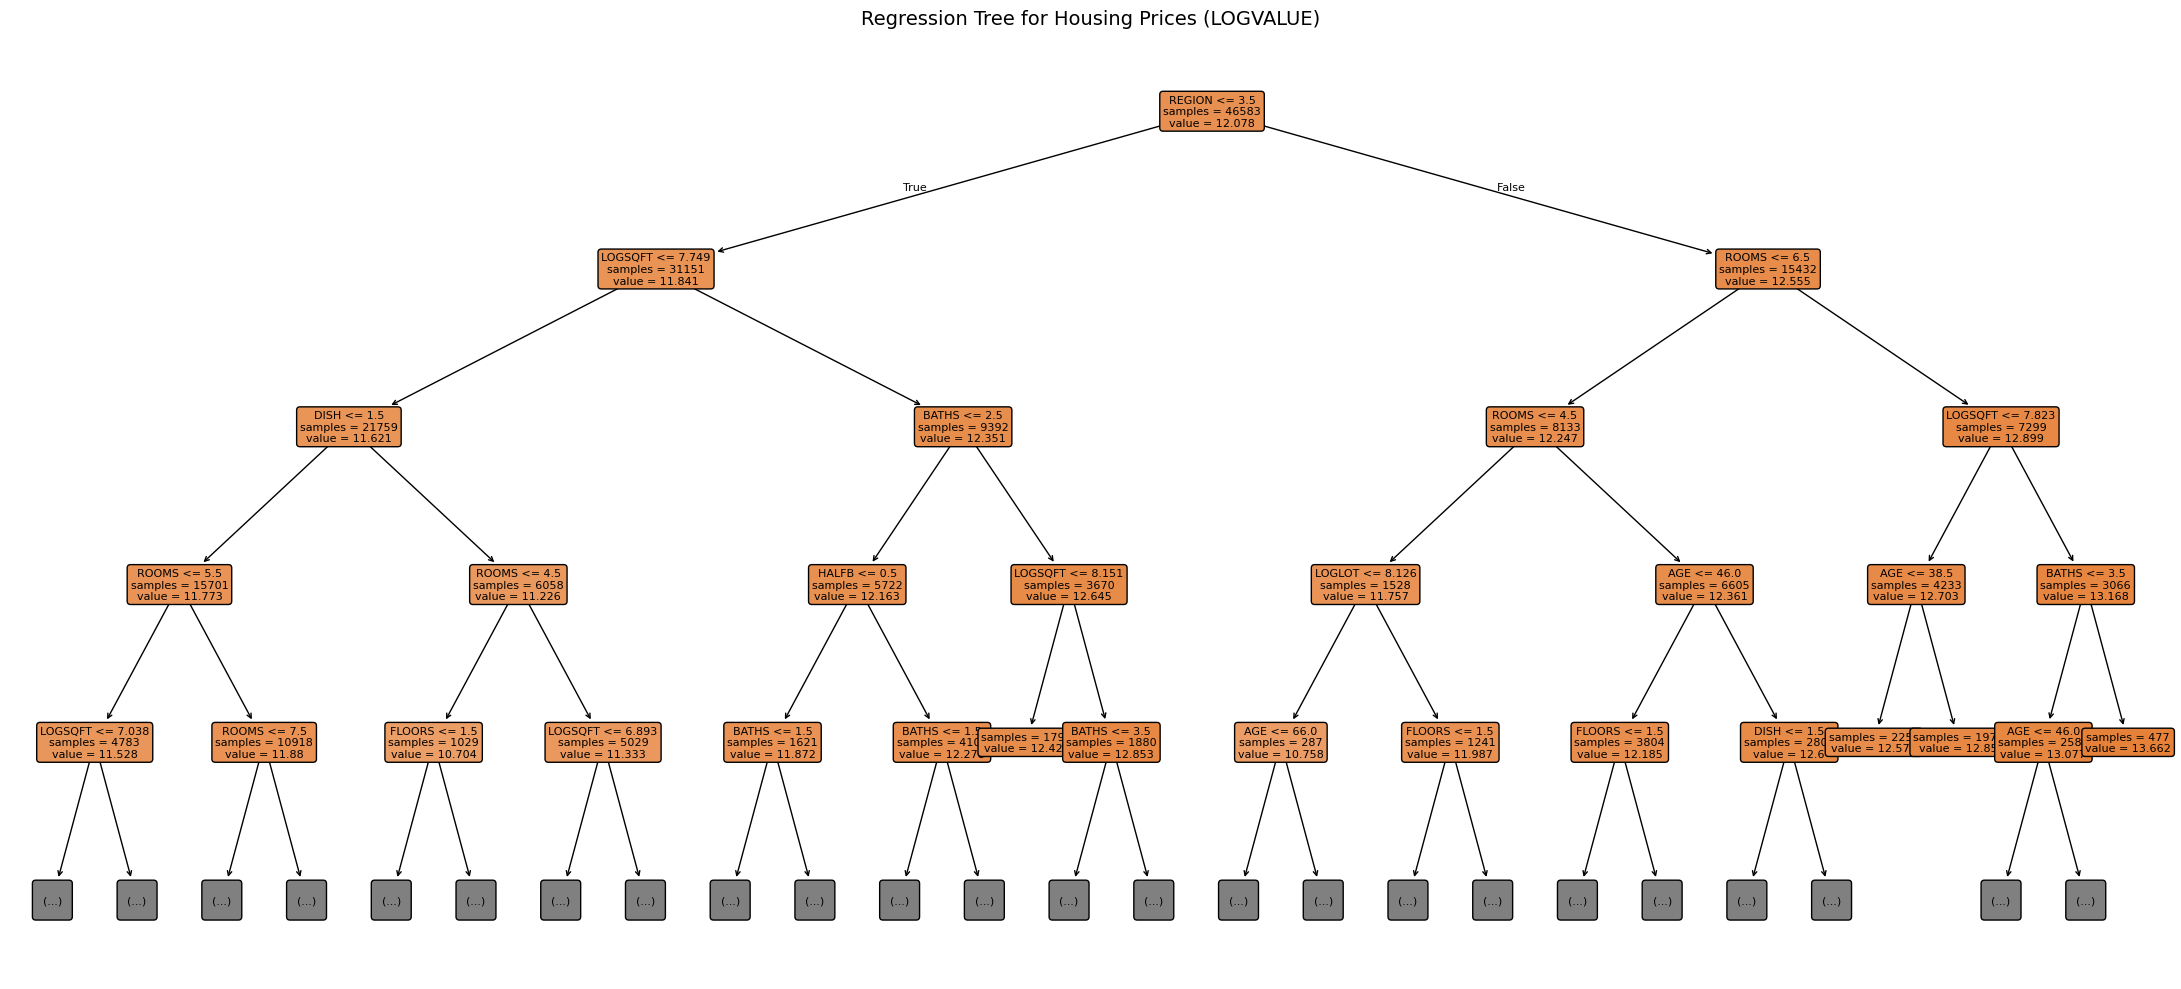

In [22]:
# Equivalent to: rpart.plot(fit_tree)
fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(
    fit_tree,
    feature_names=feature_cols,
    filled=True,
    rounded=True,
    fontsize=8,
    ax=ax,
    max_depth=4,
    impurity=False,
    precision=3
)
plt.title('Regression Tree for Housing Prices (LOGVALUE)', fontsize=14)
plt.tight_layout()
plt.show()

We see predicted (mean) values at each leaf node along with the sample count. The tree first splits on features like `REGION` and `LOGSQFT`, reflecting their high importance. Each internal node shows the split condition; follow the left branch when the condition is True.

## Performance

Let's see how we do on the validation set with this model.

In [23]:
# Equivalent to: yhat = predict(fit_tree, val1)
#                rmse = sqrt(mean((val1$LOGVALUE - yhat)^2))
X_val = val1[feature_cols].values
y_val = val1['LOGVALUE'].values

yhat_tree = fit_tree.predict(X_val)
rmse_tree = np.sqrt(mean_squared_error(y_val, yhat_tree))
print(f'\nTree RMSE: {rmse_tree:.6f}')


Tree RMSE: 0.856820


Trees are great for interpretation, but not the best for actual prediction. The RMSE we got is worse than the linear models we estimated in the previous module.

## Random Forests

One idea that is common in machine learning is to combine weak learners together and produce an ensemble. When one does this with trees the method is known as random forests. The basic idea is combine many shallow trees with only a subset of the covariates and average the predictions. As usual with these algorithms, there are many hyperparameters to choose. To get us started we will fix the number of trees we use to $10$. This is very small for a random forest, but we are just testing this out right now. A typically number of trees to use in practice would be around $200$. Another tuning parameter we need to determine is the number of covariates to split on. Remember that random forests reduce the correlation between trees by subsetting the covariates in each tree. Let's use cross-validation to determine this number over the choices $5, 20$, and $50$.

In [ ]:
mtry_values = [5, 20, 50]
kf = KFold(n_splits=5, shuffle=True, random_state=42)

rows_rf10 = []
for mtry in mtry_values:
    rf = RandomForestRegressor(
        n_estimators=10,     # num.trees = 10
        max_features=mtry,   # mtry
        min_samples_leaf=5,  # min.node.size = 5
        random_state=42,
        n_jobs=-1
    )
    cv_out = cross_validate(
        rf, X_train, y_train, cv=kf,
        scoring=['neg_root_mean_squared_error', 'r2', 'neg_mean_absolute_error']
    )
    rmse_v = -cv_out['test_neg_root_mean_squared_error']
    r2_v   =  cv_out['test_r2']
    mae_v  = -cv_out['test_neg_mean_absolute_error']
    rows_rf10.append({
        'mtry': mtry, 'splitrule': 'variance', 'min.node.size': 5,
        'RMSE'      : rmse_v.mean(),
        'Rsquared'  : r2_v.mean(),
        'MAE'       : mae_v.mean(),
        'RMSESD'    : rmse_v.std(),
        'RsquaredSD': r2_v.std(),
        'MAESD'     : mae_v.std(),
    })

fit_forest_10_results = pd.DataFrame(rows_rf10)

In [25]:
fit_forest_10_results

,mtry,splitrule,min.node.size,RMSE,Rsquared,MAE,RMSESD,RsquaredSD,MAESD
0,5,variance,5,0.762814,0.419067,0.489562,0.024132,0.019747,0.003635
1,20,variance,5,0.765116,0.415554,0.491406,0.023110,0.018340,0.003974
2,50,variance,5,0.767969,0.411168,0.492503,0.024773,0.021281,0.004557


## Evaluating Random Forests

First of all we notice that we have a big reduction in RMSE when we use random forests over trees, regardless of the tuning parameter. Secondly the performance is similar across the three specifications although we would expect the RMSE to be best when the number of covariates used is not too small or too large. Why is this? Remember that when the number of covariates used approaches the total number then we are simply bagging trees. These trees will be too highly correlated and prediction will suffer. On the other hand if we use too few covariates the trees will not be able to learn interesting patterns in the data.

## Exercise: Module 5

In this module we have seen how to build a regression tree. In addition to estimating the model we saw how easy it was to build a graph based on the tree. This graph allows for a straightforward interpretation of the model. Unfortunately, while the interpretation was very intuitive, the model performance was not very good. To fix this problem we introduced random forests and explained a few of the tuning parameters that need to be adjusted. Let's see how the results of the previous section change when we allow the number of trees to grow.

1. Use the code from the previous section to cross-validate the number of covariates to split on
2. Do this for 100 and 200 Trees
4. Do the results become more clear?

In [26]:
# Equivalent to: fit_forest = train(..., num.trees=100)
rows_rf100 = []
for mtry in mtry_values:
    rf = RandomForestRegressor(
        n_estimators=100,
        max_features=mtry,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    )
    cv_out = cross_validate(
        rf, X_train, y_train, cv=kf,
        scoring=['neg_root_mean_squared_error', 'r2', 'neg_mean_absolute_error']
    )
    rmse_v = -cv_out['test_neg_root_mean_squared_error']
    r2_v   =  cv_out['test_r2']
    mae_v  = -cv_out['test_neg_mean_absolute_error']
    rows_rf100.append({
        'mtry': mtry, 'splitrule': 'variance', 'min.node.size': 5,
        'RMSE'      : rmse_v.mean(),
        'Rsquared'  : r2_v.mean(),
        'MAE'       : mae_v.mean(),
        'RMSESD'    : rmse_v.std(),
        'RsquaredSD': r2_v.std(),
        'MAESD'     : mae_v.std(),
    })

fit_forest_100_results = pd.DataFrame(rows_rf100)

In [27]:
fit_forest_100_results

,mtry,splitrule,min.node.size,RMSE,Rsquared,MAE,RMSESD,RsquaredSD,MAESD
0,5,variance,5,0.752237,0.435066,0.479480,0.024250,0.019814,0.004222
1,20,variance,5,0.752015,0.435387,0.477981,0.023958,0.019772,0.003805
2,50,variance,5,0.755294,0.430451,0.480271,0.024265,0.020293,0.003896


In [28]:
# Equivalent to: fit_forest = train(..., num.trees=200)
rows_rf200 = []
for mtry in mtry_values:
    rf = RandomForestRegressor(
        n_estimators=200,
        max_features=mtry,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    )
    cv_out = cross_validate(
        rf, X_train, y_train, cv=kf,
        scoring=['neg_root_mean_squared_error', 'r2', 'neg_mean_absolute_error']
    )
    rmse_v = -cv_out['test_neg_root_mean_squared_error']
    r2_v   =  cv_out['test_r2']
    mae_v  = -cv_out['test_neg_mean_absolute_error']
    rows_rf200.append({
        'mtry': mtry, 'splitrule': 'variance', 'min.node.size': 5,
        'RMSE'      : rmse_v.mean(),
        'Rsquared'  : r2_v.mean(),
        'MAE'       : mae_v.mean(),
        'RMSESD'    : rmse_v.std(),
        'RsquaredSD': r2_v.std(),
        'MAESD'     : mae_v.std(),
    })

fit_forest_200_results = pd.DataFrame(rows_rf200)

In [29]:
fit_forest_200_results

,mtry,splitrule,min.node.size,RMSE,Rsquared,MAE,RMSESD,RsquaredSD,MAESD
0,5,variance,5,0.751523,0.436139,0.478898,0.024166,0.019661,0.004147
1,20,variance,5,0.751495,0.436171,0.477318,0.023989,0.019720,0.003813
2,50,variance,5,0.754591,0.431512,0.479820,0.023828,0.019644,0.003553


As we expected, when the number of trees is allowed to grow larger, the "best" performing forest is the one that splits on 20 covariates. The difference isn't substantial, but we can save ourselves some time when searching for tuning parameters by restricting the grid to values not too small and not too large.

In [ ]:
# Reproducibility info
import sklearn
print(f'Python:       {sys.version}')
print(f'NumPy:        {np.__version__}')
print(f'Pandas:       {pd.__version__}')
print(f'Matplotlib:   {matplotlib.__version__}')
print(f'scikit-learn: {sklearn.__version__}')

Python:       3.12.12 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 20:05:38) [MSC v.1929 64 bit (AMD64)]
NumPy:        1.26.4
Pandas:       2.2.2
Matplotlib:   3.10.0
scikit-learn: 1.6.1
